# Analise Exploratoria - Vacinacao contra Sarampo (SI-PNI/RNDS)

Doses de vacina com "sarampo" na descricao, filtradas do arquivo bruto de vacinacao de janeiro/2026 (`data/vacinacao/raw/vacinacao_jan_2026.csv`) via `data/vacinacao/filtrar_sarampo.py`, gerando `data/vacinacao/processed/vacinacao_sarampo_2026_jan.csv`.

Ver [02-analise-exploratoria-vacinacao.ipynb](02-analise-exploratoria-vacinacao.ipynb) para a estrutura geral das colunas e [03-analise-vacinas-geral.ipynb](03-analise-vacinas-geral.ipynb) para o panorama de todas as vacinas.

## 1. Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Paleta categorica validada (blue, orange, aqua, yellow, magenta, green, violet, red)
CATEGORICAL = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
SEQUENTIAL_BLUE = "#2a78d6"
TEXT_PRIMARY = "#0b0b0b"
TEXT_SECONDARY = "#52514e"
MUTED = "#898781"
GRID = "#e1e0d9"
SURFACE = "#fcfcfb"

plt.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "axes.edgecolor": GRID,
    "axes.labelcolor": TEXT_SECONDARY,
    "axes.grid": True,
    "grid.color": GRID,
    "grid.linewidth": 0.8,
    "text.color": TEXT_PRIMARY,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

CSV_PATH = Path("..") / "data" / "vacinacao" / "processed" / "vacinacao_sarampo_2026_jan.csv"

df = pd.read_csv(CSV_PATH)
df.shape

(684469, 56)

## 2. Vacinas de sarampo presentes na base filtrada

In [2]:
df["descricao_vacina"].value_counts()

descricao_vacina
vacina sarampo, caxumba, rubéola (atenuada)                             570617
vacina sarampo, caxumba, rubéola e varicela (atenuada)                  113446
vacina sarampo, rubéola (atenuada)                                         358
diluente para vacina sarampo, caxumba, rubéola (atenuada)                   33
vacina sarampo (atenuada)                                                   12
diluente para vacina sarampo, caxumba, rubéola e varicela (atenuada)         3
Name: count, dtype: int64

In [3]:
df["sigla_vacina"].value_counts()

sigla_vacina
SCR        570617
SCRV       113362
SR            358
SCRV-2         84
DILSCR         33
Sarampo        12
DILSCRV         3
Name: count, dtype: int64

## 3. Distribuicao temporal das doses

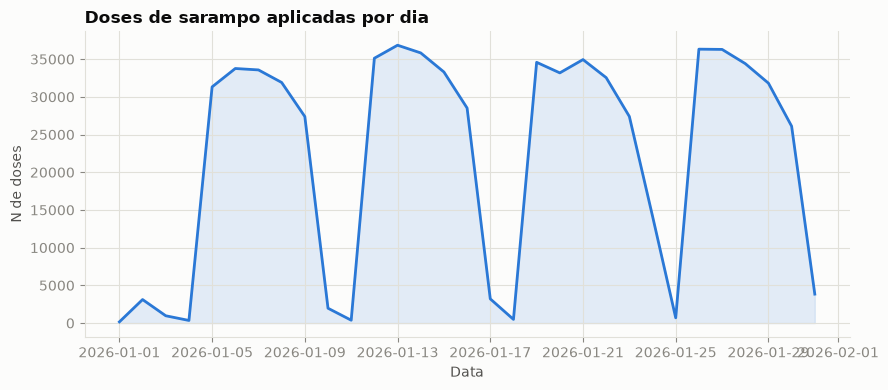

In [4]:
df["data_vacinacao"] = pd.to_datetime(df["data_vacinacao"], errors="coerce")
doses_por_dia = df["data_vacinacao"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(doses_por_dia.index, doses_por_dia.values, color=SEQUENTIAL_BLUE, linewidth=2)
ax.fill_between(doses_por_dia.index, doses_por_dia.values, color=SEQUENTIAL_BLUE, alpha=0.12)
ax.set_title("Doses de sarampo aplicadas por dia", loc="left", fontweight="bold")
ax.set_xlabel("Data")
ax.set_ylabel("N de doses")
plt.tight_layout()
plt.show()

## 4. Distribuicao geografica (UF do paciente)

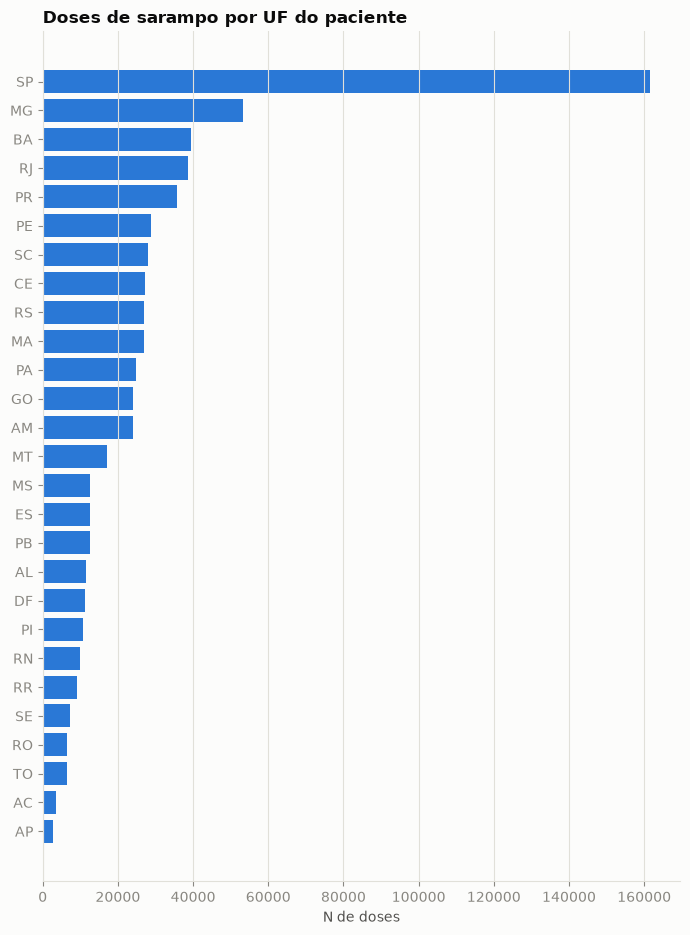

In [5]:
doses_por_uf = df["uf_paciente"].value_counts().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(7, max(4, len(doses_por_uf) * 0.35)))
ax.barh(doses_por_uf.index.astype(str), doses_por_uf.values, color=SEQUENTIAL_BLUE)
ax.set_title("Doses de sarampo por UF do paciente", loc="left", fontweight="bold")
ax.set_xlabel("N de doses")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

## 5. Perfil demografico

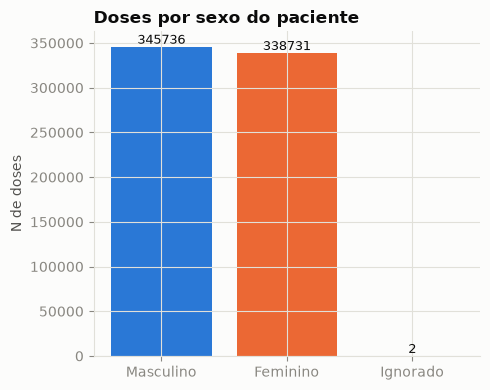

In [6]:
sexo_labels = {"M": "Masculino", "F": "Feminino", "I": "Ignorado"}
doses_por_sexo = df["sexo_paciente"].map(sexo_labels).fillna("Ignorado").value_counts()

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(doses_por_sexo.index, doses_por_sexo.values, color=CATEGORICAL[: len(doses_por_sexo)])
ax.set_title("Doses por sexo do paciente", loc="left", fontweight="bold")
ax.set_ylabel("N de doses")
for i, v in enumerate(doses_por_sexo.values):
    ax.text(i, v, str(v), ha="center", va="bottom", color=TEXT_PRIMARY, fontsize=9)
plt.tight_layout()
plt.show()

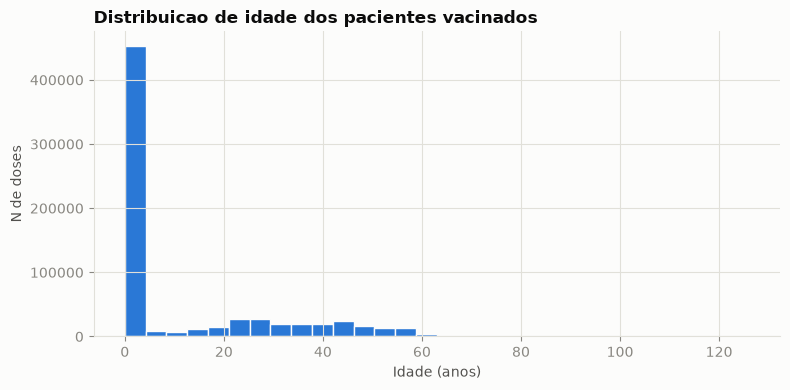

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df["idade_paciente"].dropna(), bins=30, color=SEQUENTIAL_BLUE, edgecolor=SURFACE)
ax.set_title("Distribuicao de idade dos pacientes vacinados", loc="left", fontweight="bold")
ax.set_xlabel("Idade (anos)")
ax.set_ylabel("N de doses")
plt.tight_layout()
plt.show()

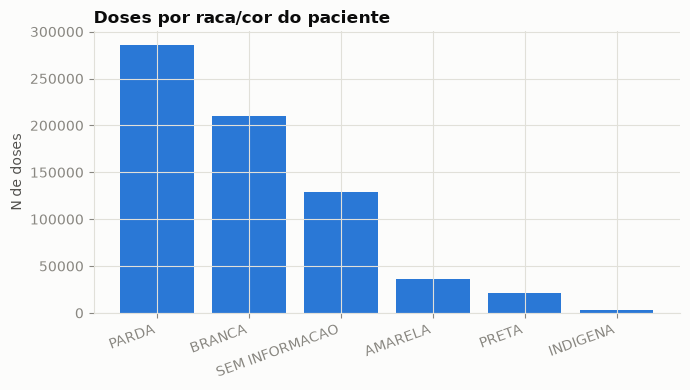

In [8]:
doses_por_raca = df["raca_cor_paciente"].fillna("Ignorado").value_counts()

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(doses_por_raca.index, doses_por_raca.values, color=SEQUENTIAL_BLUE)
ax.set_title("Doses por raca/cor do paciente", loc="left", fontweight="bold")
ax.set_ylabel("N de doses")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

## 6. Dose e estrategia de vacinacao

In [9]:
df["descricao_dose_vacina"].value_counts()

descricao_dose_vacina
1ª Dose                        300873
2ª Dose                        169112
Única                          107585
Dose                            99711
Dose Zero                        6544
1º Reforço                        202
Reforço                           153
Dose Inicial                       83
3ª Dose                            62
Dose Adicional                     46
2º Reforço                         23
1ª Dose Dobrada                    17
2ª Dose Dobrada                    16
1ª Dose Revacinação                12
Tratamento com uma dose            12
2ª Dose Revacinação                 6
4ª Dose                             5
Revacinação                         4
3ª Dose Revacinação                 1
2ª Dose Fracionada                  1
1ª Dose Revacinação Dobrada         1
Name: count, dtype: int64

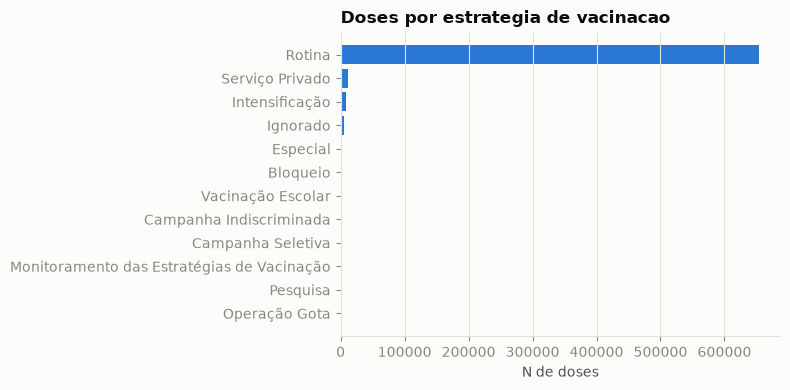

In [10]:
doses_por_estrategia = df["estrategia_vacinacao"].fillna("Ignorado").value_counts().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, max(4, len(doses_por_estrategia) * 0.3)))
ax.barh(doses_por_estrategia.index.astype(str), doses_por_estrategia.values, color=SEQUENTIAL_BLUE)
ax.set_title("Doses por estrategia de vacinacao", loc="left", fontweight="bold")
ax.set_xlabel("N de doses")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

## 7. Fabricante

In [11]:
df["fabricante_vacina"].value_counts()

fabricante_vacina
SERUM INSTITUTE OF INDIA LTD.                           531745
FUNDACAO OSWALDO CRUZ                                    57439
GLAXOSMITHKLINE BIOLOGICALS S.A. - BELGICA               38854
MERCK SHARP DOHME CO., INC.                              10156
GLAXOSMITHKLINE BEECHAM                                   6992
                                                         ...  
FINLAY VACUNAS Y SUEROS                                      1
BIOVET                                                       1
BB-NCIPD LTD.                                                1
INSTITUTO VITAL BRAZIL S.A                                   1
FARMACE INDUSTRIA QUIMICO-FARMACEUTICA CEARENSE LTDA         1
Name: count, Length: 62, dtype: int64